#Context Aware Machine Learning Model for Detecting Sarcasm and Gen Z Slangs in Youth Driven Platforms



---
## STEP 1 — Setup & Imports


In [1]:
# Install all required packages
!pip install vaderSentiment transformers torch rapidfuzz wordcloud imbalanced-learn -q

# Standard libraries
import os
import re
import pickle
import time
from collections import Counter, defaultdict

# Data / numerics
import pandas as pd
import numpy as np

#  Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#  Sklearn — preprocessing, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from rapidfuzz import process, fuzz

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)

# Google Colab
from google.colab import drive

print('All imports successful')
print(f'GPU available: {torch.cuda.is_available()}')

# Mount Google Drive so we can access our datasets and save models/cache
drive.mount('/content/drive')

# Performance flag — faster matmul on Ampere GPUs (A100, etc.)
# Has no effect on older GPUs — safe to leave on always
torch.backends.cuda.matmul.allow_tf32 = True

# Global paths — edit BASE_DIR if your files live somewhere else
# Centralised here so you only need to change one line if you reorganise Drive
BASE_DIR  = '/content/drive/My Drive/Colab Notebooks/FYP'
CACHE_DIR = f'{BASE_DIR}/cache'    # pickled intermediate results
MODEL_DIR = f'{BASE_DIR}/models'   # saved model weights
DATA_DIR  = BASE_DIR               # CSVs live at the top level

for d in [CACHE_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Cache dir : {CACHE_DIR}')
print(f'Model dir : {MODEL_DIR}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.6 MB/s eta 0:00:00
All imports successful
GPU available: True
Mounted at /content/drive
Cache dir : /content/drive/My Drive/Colab Notebooks/FYP/cache
Model dir : /content/drive/My Drive/Colab Notebooks/FYP/models


In [ ]:
def cache(key: str, fn, force_recompute: bool = False):
    """
    Compute fn() once, pickle the result to CACHE_DIR/<key>.pkl, and reload
    on subsequent calls instead of recomputing.

    Parameters
    ----------
    key            : unique filename stem (no .pkl extension needed)
    fn             : zero-argument callable that produces the result
    force_recompute: set True to ignore an existing cache and rerun fn()

    Usage
    -----
    result = cache('my_step', lambda: expensive_function(args))
    """
    path = f'{CACHE_DIR}/{key}.pkl'
    if os.path.exists(path) and not force_recompute:
        print(f'[CACHE HIT]  \'{key}\' — loading from Drive ...')
        with open(path, 'rb') as f:
            return pickle.load(f)
    print(f'[CACHE MISS] \'{key}\' — computing ...')
    t0 = time.time()
    result = fn()
    elapsed = time.time() - t0
    with open(path, 'wb') as f:
        pickle.dump(result, f)
    print(f'[SAVED]      \'{key}\' in {elapsed:.1f}s → {path}')
    return result

---
## STEP 2 — Data Loading



In [ ]:
# Load slang datasets
slang_data1 = pd.read_csv(f'{DATA_DIR}/genz_slang.csv')
slang_data2 = pd.read_csv(f'{DATA_DIR}/all_slangs.csv')

# Load main Reddit sarcasm dataset (50K sample)
sarcasm_data = pd.read_csv(f'{DATA_DIR}/SAMPLE DATASET 50K.csv')

# Verify columns
print('slang_data1 columns:', slang_data1.columns.tolist())
print('slang_data2 columns:', slang_data2.columns.tolist())
print('sarcasm_data columns:', sarcasm_data.columns.tolist())
print(f'\nDataset sizes: slang1={len(slang_data1)}, slang2={len(slang_data2)}, sarcasm={len(sarcasm_data)}')

slang_data1 columns: ['keyword', 'description']
slang_data2 columns: ['Slang', 'Description', 'Example', 'Context']
sarcasm_data columns: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', ' ', 'parent_comment']

Dataset sizes: slang1=145, slang2=1778, sarcasm=49999


---
## STEP 3 — Preprocessing


In [ ]:
# 3a. Build unified slang dictionary
# standardise both slang files
slang_data2 = slang_data2.rename(columns={'Slang': 'keyword', 'Description': 'description'})

# Merge and deduplicate
merged_slang = pd.concat(
    [slang_data1[['keyword', 'description']], slang_data2[['keyword', 'description']]],
    ignore_index=True
)
merged_slang = merged_slang.drop_duplicates(subset=['keyword'])

# Create dictionary: {slang_word: meaning}
slang_dict = dict(zip(merged_slang['keyword'].str.lower(), merged_slang['description']))
slang_terms = list(slang_dict.keys())  # needed for fuzzy matching later

print(f'Slang dictionary size: {len(slang_dict)} terms')
print('Sample entries:', list(slang_dict.items())[:5])

Slang dictionary size: 1586 terms
Sample entries: [('w', 'Shorthand for win'), ('l', 'Shorthand for loss/losing'), ('l+ratio', 'Response to a comment or action on the internet that is particularly bad.'), ('dank', 'excellent or of very high quality'), ('cheugy', 'Derogatory term for Millennials. Used when millennials are perceived to be excessively attempting to be trendy or stylish.')]


In [ ]:
#  3b. Clean the sarcasm dataset
# Drop columns
columns_to_drop = [' ', 'author', 'ups', 'downs', 'date']
sarcasm_data = sarcasm_data.drop(columns=columns_to_drop, errors='ignore')

# Handle missing values and duplicates
print('Missing values before cleaning:')
print(sarcasm_data.isna().sum())
print(f'Duplicates: {sarcasm_data.duplicated().sum()}')

sarcasm_data = sarcasm_data.dropna()
sarcasm_data = sarcasm_data.drop_duplicates()

# Rename 'label' to 'sarcasm_flag'
sarcasm_data = sarcasm_data.rename(columns={'label': 'sarcasm_flag'})

print(f'\nDataset shape after cleaning: {sarcasm_data.shape}')

Missing values before cleaning:
label             0
comment           2
subreddit         0
score             0
parent_comment    0
dtype: int64
Duplicates: 7

Dataset shape after cleaning: (49990, 5)


In [ ]:
#  3c. Data type verification
# Checking data types ensures columns are the correct format before modelling
print('=== Data types ===')
print(sarcasm_data.dtypes)
print(f'\nsarcasm_flag unique values: {sorted(sarcasm_data["sarcasm_flag"].unique())}')
print(f'Expected: [0, 1]')

=== Data types ===
sarcasm_flag       int64
comment           object
subreddit         object
score              int64
parent_comment    object
dtype: object

sarcasm_flag unique values: [np.int64(0), np.int64(1)]
Expected: [0, 1]


In [ ]:
#  3d. Build full_text field
# Combine the comment with its parent comment.
# This gives the model CONTEXT.
sarcasm_data['parent_comment'] = sarcasm_data['parent_comment'].fillna('')
sarcasm_data['full_text'] = (
    sarcasm_data['comment'] + ' [ ' + sarcasm_data['parent_comment'] + ']'
)

print('full_text sample:')
print(sarcasm_data['full_text'].iloc[0])

full_text sample:
NC and NH. [ Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well.]


---
## STEP 4 — Improved Slang Detection (v2)


In [ ]:
#  4a. Original rule-based slang detector (for comparison)
def detect_slang_v1(comment, slang_dict):
    """Original exact-match detector from IPD."""
    if not isinstance(comment, str):
        return 0, ''
    words = re.findall(r'\b\w+\b', comment.lower())
    detected = set()
    contexts = []
    for word in words:
        if word in slang_dict:
            detected.add(word)
            contexts.append(f'{word}: {slang_dict[word]}')
    flag = 1 if detected else 0
    context = '; '.join(contexts) if contexts else ''
    return flag, context

# Run v1 — cached so this executes only once
sarcasm_data[['slang_flag_v1', 'slang_context_v1']] = cache(
    'slang_v1',
    lambda: sarcasm_data['full_text'].apply(
        lambda x: pd.Series(detect_slang_v1(x, slang_dict))
    ),
)
print(f'v1 slang detection rate: {sarcasm_data["slang_flag_v1"].mean():.1%}')

[CACHE MISS] 'slang_v1' — computing ...
[SAVED]      'slang_v1' in 24.5s → /content/drive/My Drive/Colab Notebooks/FYP/cache/slang_v1.pkl
v1 slang detection rate: 51.6%


In [ ]:
#IMPROVED SLANG DETECTOR V2
#  4b. Build optimized lookup structures for v2
slang_set = set(slang_dict.keys())   # O(1) exact lookup — faster than dict key check

# Prefix index: first 3 chars of each slang term

prefix_index: dict = defaultdict(list)
for term in slang_terms:
    if isinstance(term, str) and len(term) >= 3:
        prefix_index[term[:3]].append(term)

# Gen-Z multi-word patterns pre-compiled into ONE combined regex
# Single re.compile() at load time instead of re.search() per pattern per comment
GENZ_PATTERNS = [
    r'\bfr\s?fr\b',
    r'\bno\s?cap\b',
    r'\bim\s?dead\b',
    r'\bngl\b',
    r'\bidk\b',
    r'\bperiodt?\b',
    r'\bslay+\b',
    r'\blow\s?key\b',
    r'\bhigh\s?key\b',
    r'\bboutta\b',
    r'\bvibing\b',
    r'\bsnatched\b',
    r'\bate\s+(that\s+)?(and\s+left\s+no\s+crumbs?)?\b',
    r'\brent\s?free\b',
    r'\bit\s?gives?\b',
    r"\bchef'?s\s?kiss\b",
]
COMBINED_PATTERN = re.compile('|'.join(GENZ_PATTERNS), re.IGNORECASE)


def detect_slang_v2(comment: str, threshold: int = 85):
    """
    Optimized three-layer slang detector.

    Layer 1 — Exact match        : O(1) set lookup per word
    Layer 2 — Prefix-gated fuzzy : fuzzy only when prefix matches → ~5 candidates
    Layer 3 — Pre-compiled regex : single pass for multi-word Gen-Z constructions

    Parameters
    ----------
    comment   : raw comment string
    threshold : minimum rapidfuzz ratio score to accept a fuzzy match (0–100)
    """
    if not isinstance(comment, str):
        return 0, ''

    text_lower = comment.lower()
    words      = re.findall(r'\b\w+\b', text_lower)
    detected   = set()

    for word in words:
        if len(word) < 3:      # skip very short words — too many false positives
            continue
        # Layer 1: exact match — fastest check, done first
        if word in slang_set:
            detected.add(word)
            continue
        # Layer 2: fuzzy — only run if the 3-char prefix exists in the index

        candidates = prefix_index.get(word[:3], [])
        if candidates:
            match, score, _ = process.extractOne(
                word, candidates, scorer=fuzz.ratio
            )
            if score >= threshold:
                detected.add(match)

    # Layer 3: pre-compiled combined regex — catches multi-word constructions

    for m in COMBINED_PATTERN.finditer(text_lower):
        detected.add(m.group().strip())

    return (1 if detected else 0), ', '.join(detected)

In [ ]:
# Run v2 — cached so this executes only once across all Colab sessions
sarcasm_data[['slang_flag_v2', 'slang_context_v2']] = cache(
    'slang_v2',
    lambda: sarcasm_data['full_text'].apply(
        lambda x: pd.Series(detect_slang_v2(x))
    ),
)

print(f'v1 slang detection rate : {sarcasm_data["slang_flag_v1"].mean():.1%}')
print(f'v2 slang detection rate : {sarcasm_data["slang_flag_v2"].mean():.1%}')
newly = (
    (sarcasm_data['slang_flag_v1'] == 0) & (sarcasm_data['slang_flag_v2'] == 1)
).sum()
print(f'Newly detected by v2    : {newly} comments')
print('\nThis improvement comes from fuzzy matching and multi-word regex patterns.')

[CACHE MISS] 'slang_v2' — computing ...
[SAVED]      'slang_v2' in 22.0s → /content/drive/My Drive/Colab Notebooks/FYP/cache/slang_v2.pkl
v1 slang detection rate : 51.6%
v2 slang detection rate : 56.5%
Newly detected by v2    : 9897 comments

This improvement comes from fuzzy matching and multi-word regex patterns.


---
## STEP 5 — Improved Sentiment Labelling (v2 — RoBERTa)


In [ ]:
# 5a. Original VADER sentiment (for comparison)
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_v1(text, sarcasm_flag):
    """Original VADER with sarcasm inversion from IPD."""
    if not isinstance(text, str):
        return 0
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if sarcasm_flag == 1:
        compound = -compound   # flip score if sarcastic
    if compound >= 0.05:
        return 2   # Positive
    elif compound <= -0.05:
        return 1   # Negative
    else:
        return 0   # Neutral

sarcasm_data['sentiment_v1'] = cache(
    'sentiment_v1',
    lambda: sarcasm_data.apply(
        lambda row: get_sentiment_v1(row['full_text'], row['sarcasm_flag']), axis=1
    ),
)
print('VADER sentiment distribution:')
print(sarcasm_data['sentiment_v1'].value_counts().sort_index())

[CACHE MISS] 'sentiment_v1' — computing ...
[SAVED]      'sentiment_v1' in 31.7s → /content/drive/My Drive/Colab Notebooks/FYP/cache/sentiment_v1.pkl
VADER sentiment distribution:
sentiment_v1
0     7837
1    20175
2    21978
Name: count, dtype: int64


In [ ]:
# 5b. RoBERTa sentiment (v2)
# cardiffnlp/twitter-roberta-base-sentiment-latest is trained on 124M tweets.

ROBERTA_PARTIAL = f'{CACHE_DIR}/roberta_sentiments.pkl'

def run_roberta_labelling():
    print('Loading Twitter-RoBERTa ...')
    sentiment_pipe = pipeline(
        'sentiment-analysis',
        model='cardiffnlp/twitter-roberta-base-sentiment-latest',
        tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest',
        max_length=512,
        truncation=True,
        device=0 if torch.cuda.is_available() else -1,
    )
    label_map  = {'negative': 1, 'neutral': 0, 'positive': 2}
    texts      = sarcasm_data['full_text'].str[:512].tolist()
    chunk_size = 1024   # was 256 — 4x fewer Python loop iterations
    sentiments = []

    # Resume from partial save if one exists (crash recovery)

    if os.path.exists(ROBERTA_PARTIAL):
        with open(ROBERTA_PARTIAL, 'rb') as f:
            sentiments = pickle.load(f)
        start = len(sentiments)
        print(f'Resuming from row {start} / {len(texts)}')
    else:
        start = 0

    print(f'Running RoBERTa from row {start} (~10-15 min on T4 GPU) ...')
    for i in range(start, len(texts), chunk_size):
        chunk   = texts[i : i + chunk_size]
        results = sentiment_pipe(
            chunk,
            truncation=True,
            max_length=512,
            batch_size=64,   # explicit batch size — better GPU utilisation
        )
        sentiments.extend([label_map[r['label'].lower()] for r in results])

        # Incremental partial save every 10K rows

        if (i - start) % 10_000 == 0 and i > start:
            with open(ROBERTA_PARTIAL, 'wb') as f:
                pickle.dump(sentiments, f)
            print(f'  Partial save at row {i} / {len(texts)}')

    # Final save
    with open(ROBERTA_PARTIAL, 'wb') as f:
        pickle.dump(sentiments, f)
    return sentiments

sarcasm_data['sentiment_v2'] = cache('sentiment_v2', run_roberta_labelling)

print('\nRoBERTa sentiment distribution:')
print(sarcasm_data['sentiment_v2'].value_counts().sort_index())

[CACHE MISS] 'sentiment_v2' — computing ...
Loading Twitter-RoBERTa ...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Running RoBERTa from row 0 (~10-15 min on T4 GPU) ...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[SAVED]      'sentiment_v2' in 377.5s → /content/drive/My Drive/Colab Notebooks/FYP/cache/sentiment_v2.pkl

RoBERTa sentiment distribution:
sentiment_v2
0    20481
1    20541
2     8968
Name: count, dtype: int64


Overall agreement rate (VADER vs RoBERTa): 38.1%
Agreement on Non-sarcastic comments: 50.3%
Agreement on Sarcastic comments: 25.9%


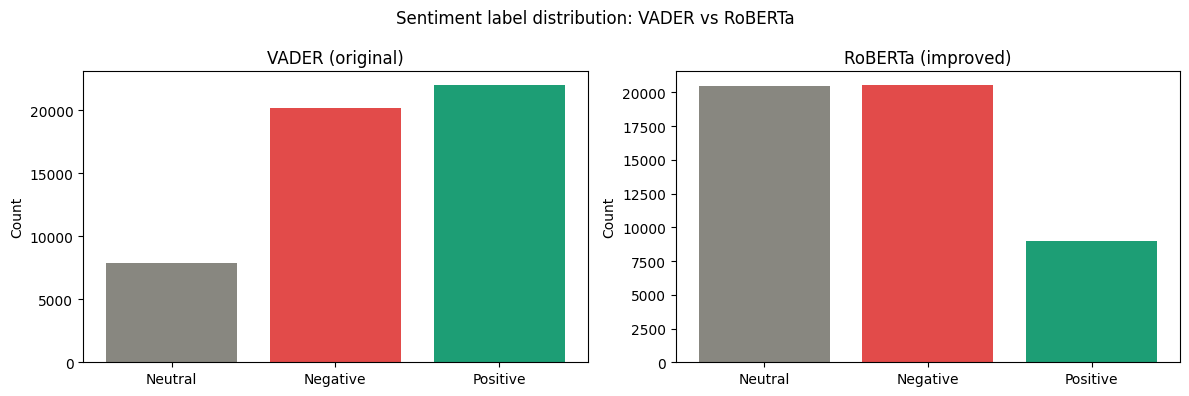


Sentiment labels changed: 30928 rows (61.9%)


In [ ]:
#  5c. Compare VADER vs RoBERTa

agreement = (sarcasm_data['sentiment_v1'] == sarcasm_data['sentiment_v2']).mean()
print(f'Overall agreement rate (VADER vs RoBERTa): {agreement:.1%}')

# Agreement broken down by sarcasm — the key insight
for sarc_val, label in [(0, 'Non-sarcastic'), (1, 'Sarcastic')]:
    subset = sarcasm_data[sarcasm_data['sarcasm_flag'] == sarc_val]
    agr = (subset['sentiment_v1'] == subset['sentiment_v2']).mean()
    print(f'Agreement on {label} comments: {agr:.1%}')

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
    ['sentiment_v1', 'sentiment_v2'],
    ['VADER (original)', 'RoBERTa (improved)']):
    counts = sarcasm_data[col].value_counts().sort_index()
    ax.bar(['Neutral', 'Negative', 'Positive'], counts.values,
           color=['#888780', '#E24B4A', '#1D9E75'])
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.suptitle('Sentiment label distribution: VADER vs RoBERTa')
plt.tight_layout()
plt.show()

# Save label change stats for the report
changed = (sarcasm_data['sentiment_v1'] != sarcasm_data['sentiment_v2']).sum()
print(f'\nSentiment labels changed: {changed} rows ({changed/len(sarcasm_data):.1%})')

In [ ]:
# 5d. Build final dataset with improved labels
# use v2 labels (RoBERTa sentiment + improved slang) for all modelling.

sarcasm_data['slang_flag']    = sarcasm_data['slang_flag_v2']
sarcasm_data['slang_context'] = sarcasm_data['slang_context_v2']
sarcasm_data['sentiment']     = sarcasm_data['sentiment_v2']

user_comments_data = sarcasm_data.copy()
print('Final dataset preview:')
user_comments_data[['full_text','sarcasm_flag','slang_flag','sentiment']].head()

Final dataset preview:


,full_text,sarcasm_flag,slang_flag,sentiment
0,"NC and NH. [ Yeah, I get that argument. At thi...",0,0,0
1,You do know west teams play against west teams...,0,0,1
2,"They were underdogs earlier today, but since G...",0,0,0
3,"This meme isn't funny none of the ""new york ni...",0,0,1
4,I could use one of those tools. [ Yep can conf...,0,1,2


---
## STEP 6 — Data Cleaning


In [ ]:
def clean_text(text):
    """Remove noise from text while preserving slang-relevant content."""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # URLs
    text = re.sub(r'@\w+', '', text)           # @mentions
    text = re.sub(r'#(\w+)', r'\1', text)      # remove # but keep the word (slang hashtags)
    text = re.sub(r'\s+', ' ', text).strip()   # extra spaces
    return text

user_comments_data['full_text'] = user_comments_data['full_text'].apply(clean_text)

# Remove very short comments — they have no meaningful signal
before = len(user_comments_data)
user_comments_data = user_comments_data[
    user_comments_data['full_text'].str.strip().str.len() > 10
]

# Remove duplicate comments
user_comments_data = user_comments_data.drop_duplicates(subset=['full_text'])
after = len(user_comments_data)

print(f'Removed {before - after} rows (short/duplicate)')
print(f'Dataset size: {after} rows')

Removed 65 rows (short/duplicate)
Dataset size: 49925 rows


In [ ]:
# Add text length as a metadata feature.
# Sarcastic comments tend to be shorter and punchier — this is a useful signal
user_comments_data['text_len'] = user_comments_data['full_text'].apply(len)

# Build the final clean dataset with only the need columns
final_user_comments = user_comments_data[
    ['full_text','sarcasm_flag','slang_flag','slang_context',
     'sentiment','sentiment_v1','text_len']
].dropna().reset_index(drop=True)

print('Final dataset shape:', final_user_comments.shape)
print('\nData types:')
print(final_user_comments.dtypes)
print('\nValue ranges:')
print(f'sarcasm_flag: {sorted(final_user_comments["sarcasm_flag"].unique())}')
print(f'slang_flag:   {sorted(final_user_comments["slang_flag"].unique())}')
print(f'sentiment:    {sorted(final_user_comments["sentiment"].unique())}')
print(f'text_len:     min={final_user_comments["text_len"].min()}, '
      f'max={final_user_comments["text_len"].max()}, '
      f'mean={final_user_comments["text_len"].mean():.1f}')
print('\nNull check:')
print(final_user_comments.isnull().sum())

Final dataset shape: (49925, 7)

Data types:
full_text        object
sarcasm_flag      int64
slang_flag        int64
slang_context    object
sentiment         int64
sentiment_v1      int64
text_len          int64
dtype: object

Value ranges:
sarcasm_flag: [np.int64(0), np.int64(1)]
slang_flag:   [np.int64(0), np.int64(1)]
sentiment:    [np.int64(0), np.int64(1), np.int64(2)]
text_len:     min=11, max=20002, mean=193.1

Null check:
full_text        0
sarcasm_flag     0
slang_flag       0
slang_context    0
sentiment        0
sentiment_v1     0
text_len         0
dtype: int64


---
## STEP 7 — Deep EDA


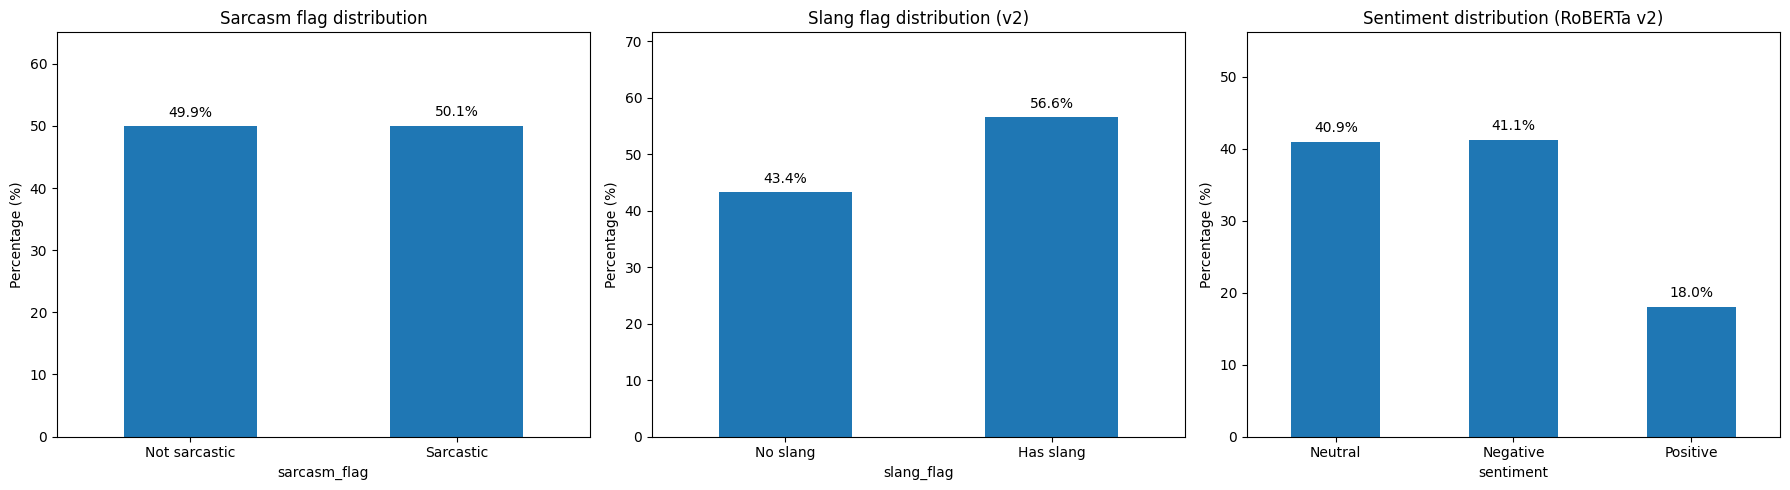

In [ ]:
# 7a. Distribution bar plot
def distribution_plots(field_name, ax, title=None, labels=None):
    counts = final_user_comments[field_name].value_counts(normalize=True).sort_index() * 100
    bars = counts.plot(kind='bar', ax=ax)
    for bar in bars.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(title or f'Distribution of {field_name}')
    ax.set_xlabel(field_name)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, max(counts) + 15)
    ax.tick_params(axis='x', rotation=0)
    if labels:
        ax.set_xticklabels(labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
distribution_plots('sarcasm_flag', axes[0], 'Sarcasm flag distribution',
                   labels=['Not sarcastic','Sarcastic'])
distribution_plots('slang_flag', axes[1], 'Slang flag distribution (v2)',
                   labels=['No slang','Has slang'])
distribution_plots('sentiment', axes[2], 'Sentiment distribution (RoBERTa v2)',
                   labels=['Neutral','Negative','Positive'])
plt.tight_layout()
plt.show()

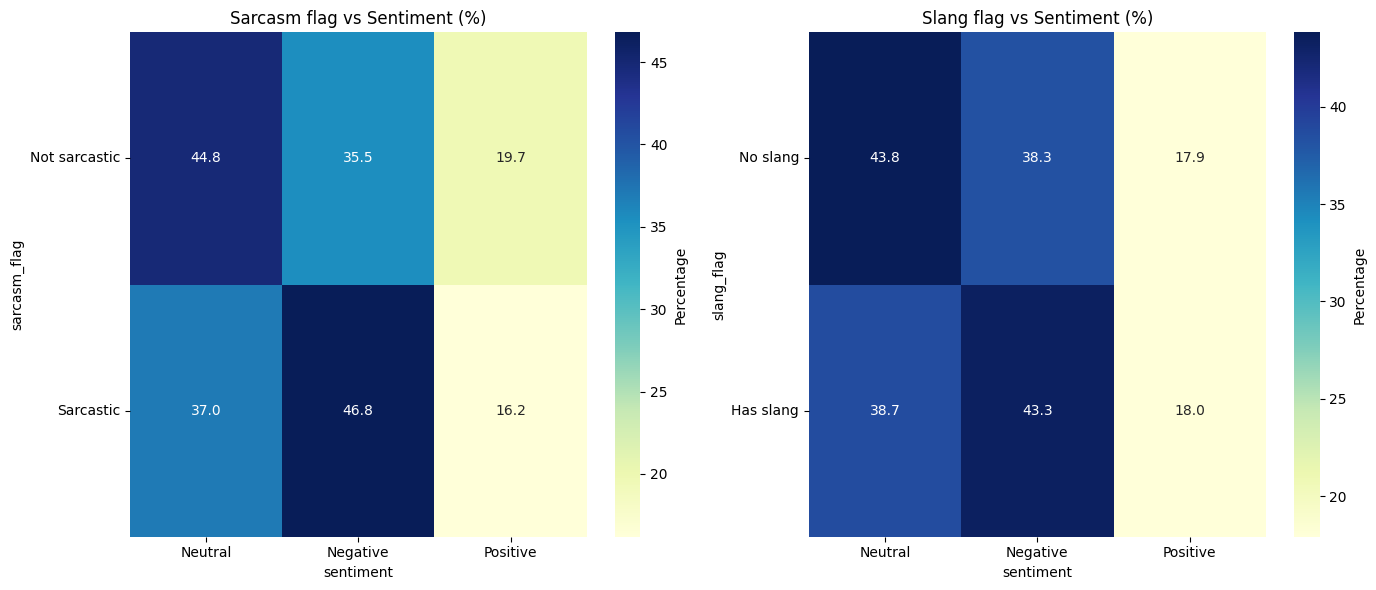

In [ ]:
#  7b. Cross-tab heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    pd.crosstab(final_user_comments['sarcasm_flag'],
                final_user_comments['sentiment'], normalize='index') * 100,
    annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0],
    cbar_kws={'label': 'Percentage'}
)
axes[0].set_title('Sarcasm flag vs Sentiment (%)')
axes[0].set_xticklabels(['Neutral','Negative','Positive'])
axes[0].set_yticklabels(['Not sarcastic','Sarcastic'], rotation=0)

sns.heatmap(
    pd.crosstab(final_user_comments['slang_flag'],
                final_user_comments['sentiment'], normalize='index') * 100,
    annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
    cbar_kws={'label': 'Percentage'}
)
axes[1].set_title('Slang flag vs Sentiment (%)')
axes[1].set_xticklabels(['Neutral','Negative','Positive'])
axes[1].set_yticklabels(['No slang','Has slang'], rotation=0)

plt.tight_layout()
plt.show()

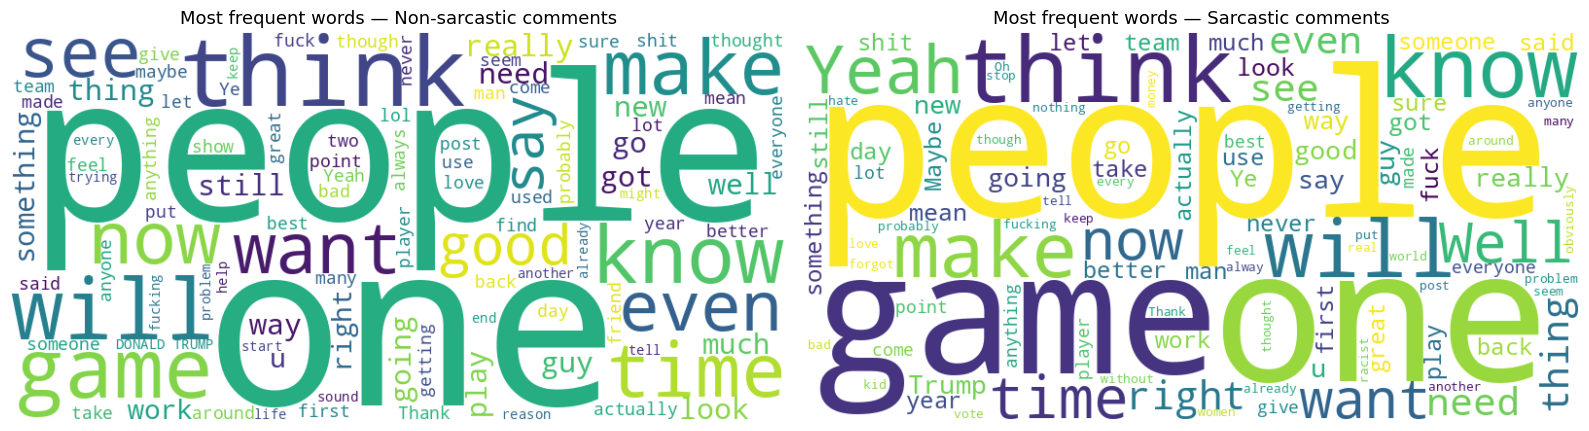

In [ ]:
# 7c. Word clouds
# Shows which words dominate sarcastic vs non-sarcastic comments visually
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label, name in [(axes[0], 0, 'Non-sarcastic'), (axes[1], 1, 'Sarcastic')]:
    text = ' '.join(
        final_user_comments[final_user_comments['sarcasm_flag'] == label]['full_text']
    )
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Most frequent words — {name} comments', fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()

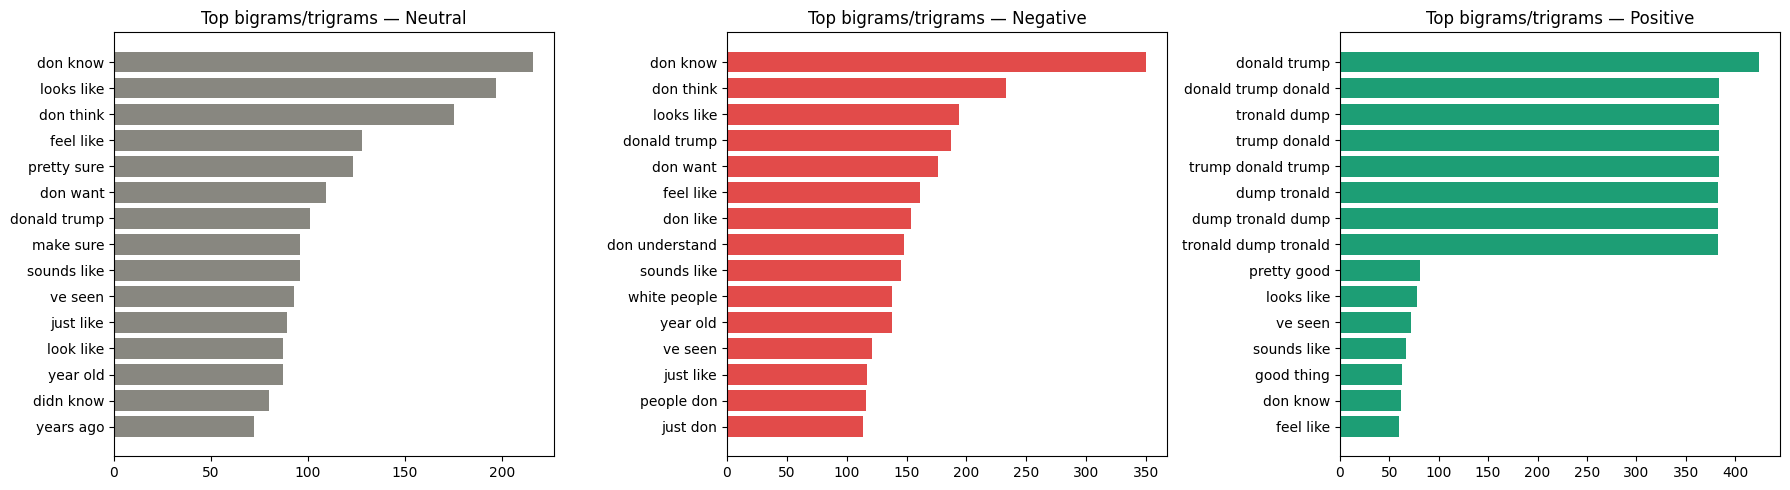

In [ ]:
#  7d. Top bigrams by sentiment
# Shows what phrase patterns differ across positive, negative, and neutral comments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sentiment, name in zip(axes, [0, 1, 2], ['Neutral', 'Negative', 'Positive']):
    subset = final_user_comments[
        final_user_comments['sentiment'] == sentiment
    ]['full_text']
    vec = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=15)
    X = vec.fit_transform(subset)
    freq = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top = sorted(zip(terms, freq), key=lambda x: -x[1])[:15]
    words, counts = zip(*top)
    ax.barh(words, counts, color=['#888780','#E24B4A','#1D9E75'][sentiment])
    ax.set_title(f'Top bigrams/trigrams — {name}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

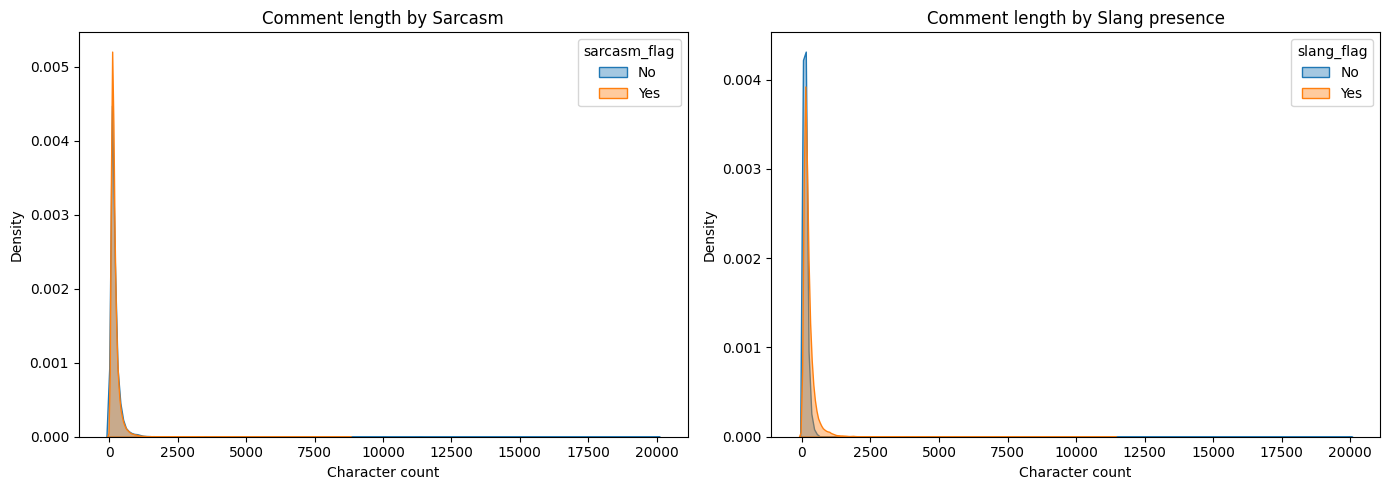

Mean comment length by sarcasm:
                count   mean    std   min   25%    50%    75%      max
sarcasm_flag                                                          
0             24932.0  195.3  297.0  11.0  81.0  132.0  219.0  20002.0
1             24993.0  191.0  221.9  11.0  92.0  136.0  215.0   8751.0


In [ ]:
# 7e. Text length distribution by sarcasm and slang
# Sarcastic comments are often shorter and punchier than genuine ones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['sarcasm_flag', 'slang_flag'],
    ['Comment length by Sarcasm', 'Comment length by Slang presence']
):
    for val, label in [(0, 'No'), (1, 'Yes')]:
        subset = final_user_comments[final_user_comments[col] == val]['text_len']
        sns.kdeplot(subset, ax=ax, label=label, fill=True, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('Character count')
    ax.set_ylabel('Density')
    ax.legend(title=col)
plt.tight_layout()
plt.show()

# Summary stats
print('Mean comment length by sarcasm:')
print(final_user_comments.groupby('sarcasm_flag')['text_len'].describe().round(1))

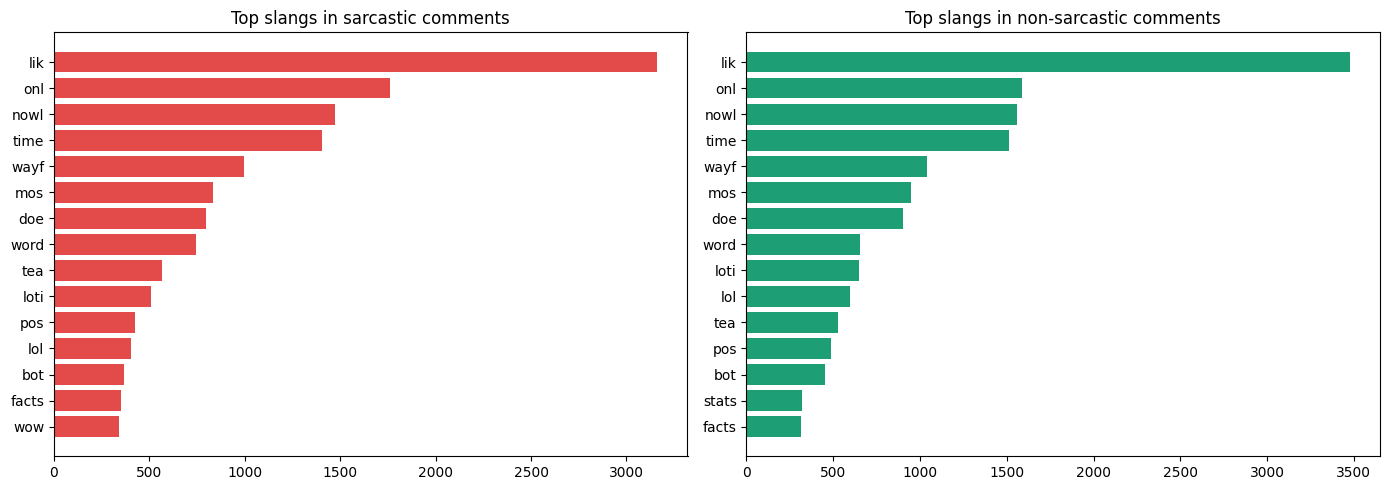

In [ ]:
#  7f. Slang co-occurrence with sarcasm
# Which specific slang terms appear most in sarcastic vs non-sarcastic comments?
sarcastic_slangs = []
non_sarcastic_slangs = []

for _, row in final_user_comments[final_user_comments['slang_flag'] == 1].iterrows():
    terms = [t.strip() for t in str(row['slang_context']).split(',') if t.strip()]
    if row['sarcasm_flag'] == 1:
        sarcastic_slangs.extend(terms)
    else:
        non_sarcastic_slangs.extend(terms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in zip(
    axes,
    [sarcastic_slangs, non_sarcastic_slangs],
    ['Top slangs in sarcastic comments', 'Top slangs in non-sarcastic comments'],
    ['#E24B4A', '#1D9E75']
):
    if not data:
        ax.text(0.5, 0.5, 'No data', ha='center')
        continue
    top = Counter(data).most_common(15)
    words, counts = zip(*top)
    ax.barh(words, counts, color=color)
    ax.set_title(title)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## STEP 8 — Dataset Split + TF-IDF Features


In [ ]:
# Stratified 70 / 15 / 15 split — cached so all sessions use identical splits
def build_splits():
    train_val, test = train_test_split(
        final_user_comments, test_size=0.15, random_state=42,
        stratify=final_user_comments['sentiment']
    )
    train, val = train_test_split(
        train_val, test_size=0.1765, random_state=42,
        stratify=train_val['sentiment']
    )
    return train, val, test

train, val, test = cache('splits', build_splits)

print(f'Train: {len(train):,} rows')
print(f'Val:   {len(val):,} rows')
print(f'Test:  {len(test):,} rows')
print('\nSentiment distribution in train:')
print(train['sentiment'].value_counts(normalize=True).round(3))

[CACHE MISS] 'splits' — computing ...
[SAVED]      'splits' in 0.0s → /content/drive/My Drive/Colab Notebooks/FYP/cache/splits.pkl
Train: 34,946 rows
Val:   7,490 rows
Test:  7,489 rows

Sentiment distribution in train:
sentiment
1    0.411
0    0.409
2    0.180
Name: proportion, dtype: float64


In [ ]:
# TF-IDF vectorisation — cached — fit ONLY on training data
# max_features=8000 keeps memory manageable on Colab
# ngram_range=(1,2) captures single words AND two-word phrases like 'not good'
# min_df=5 removes very rare terms that appear in fewer than 5 documents

def build_tfidf_features():
    vec = TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        min_df=5,
        stop_words='english'
    )
    scaler = StandardScaler()

    X_train_text = vec.fit_transform(train['full_text'])
    X_val_text   = vec.transform(val['full_text'])
    X_test_text  = vec.transform(test['full_text'])

    # Scale text_len metadata feature and combine with TF-IDF
    X_train_meta = scaler.fit_transform(train[['text_len']])
    X_val_meta   = scaler.transform(val[['text_len']])
    X_test_meta  = scaler.transform(test[['text_len']])

    return (
        hstack([X_train_text, X_train_meta]),
        hstack([X_val_text,   X_val_meta]),
        hstack([X_test_text,  X_test_meta]),
        vec,
        scaler,
    )

X_train, X_val, X_test, vectorizer, scaler = cache('tfidf_features', build_tfidf_features)

y_train = train['sentiment']
y_val   = val['sentiment']
y_test  = test['sentiment']

print('Feature matrix shapes:')
print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

[CACHE MISS] 'tfidf_features' — computing ...
[SAVED]      'tfidf_features' in 3.4s → /content/drive/My Drive/Colab Notebooks/FYP/cache/tfidf_features.pkl
Feature matrix shapes:
X_train: (34946, 8001)
X_val:   (7490, 8001)
X_test:  (7489, 8001)


---
## STEP 9 — Baseline ML Models




=== Logistic Regression ===
              precision    recall  f1-score   support

     Neutral       0.65      0.66      0.65      3064
    Negative       0.73      0.66      0.69      3081
    Positive       0.55      0.64      0.59      1345

    accuracy                           0.66      7490
   macro avg       0.64      0.65      0.65      7490
weighted avg       0.66      0.66      0.66      7490



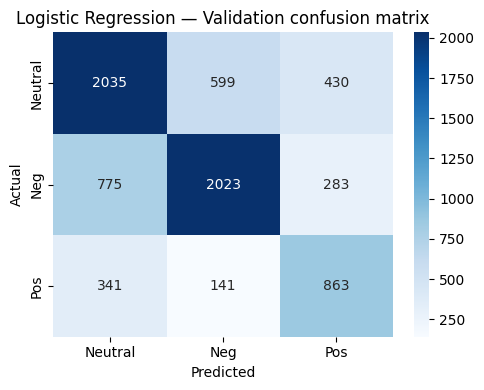


=== Linear SVM ===
              precision    recall  f1-score   support

     Neutral       0.62      0.64      0.63      3064
    Negative       0.71      0.66      0.68      3081
    Positive       0.53      0.56      0.54      1345

    accuracy                           0.64      7490
   macro avg       0.62      0.62      0.62      7490
weighted avg       0.64      0.64      0.64      7490



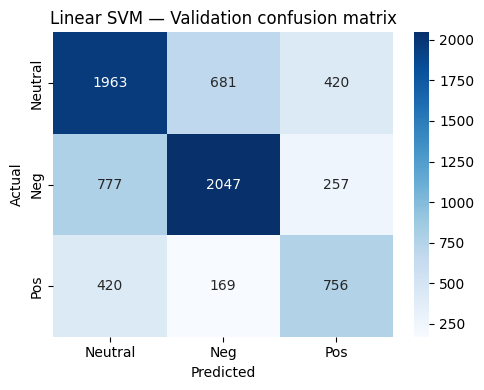


=== Random Forest ===
              precision    recall  f1-score   support

     Neutral       0.61      0.66      0.63      3064
    Negative       0.66      0.67      0.67      3081
    Positive       0.59      0.46      0.52      1345

    accuracy                           0.63      7490
   macro avg       0.62      0.60      0.60      7490
weighted avg       0.63      0.63      0.62      7490



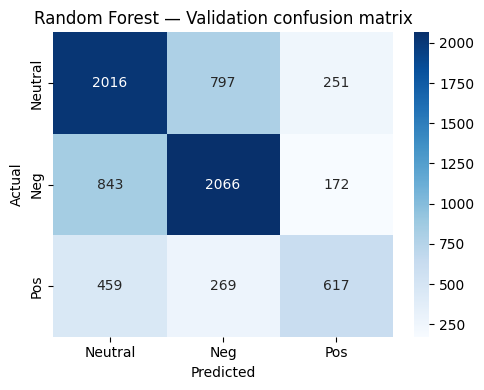

In [ ]:
#  9a. Train baseline models
# class_weight='balanced' tells the model to pay more attention to minority classes
baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced', max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

baseline_results = {}

for name, model in baseline_models.items():
    print(f'\n=== {name} ===')
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)

    print(classification_report(
        y_val, val_preds,
        target_names=['Neutral', 'Negative', 'Positive']
    ))

    f1 = f1_score(y_val, val_preds, average='weighted')
    acc = accuracy_score(y_val, val_preds)
    baseline_results[name] = {'f1': f1, 'accuracy': acc}

    # Individual confusion matrix — makes it easy to spot which classes are confused
    cm = confusion_matrix(y_val, val_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Neutral','Neg','Pos'],
                yticklabels=['Neutral','Neg','Pos'],
                cmap='Blues')
    plt.title(f'{name} — Validation confusion matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [ ]:
# 9b. Apply SMOTE and retrain
# SMOTE creates synthetic training samples for minority classes.
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('Class distribution before SMOTE:', Counter(y_train))
print('Class distribution after SMOTE: ', Counter(y_train_sm))

smote_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_sm, y_train_sm)
    val_preds = model.predict(X_val)
    f1 = f1_score(y_val, val_preds, average='weighted')
    acc = accuracy_score(y_val, val_preds)
    smote_results[name + ' (SMOTE)'] = {'f1': f1, 'accuracy': acc}
    print(f'{name} + SMOTE — Val F1: {f1:.3f}')

Class distribution before SMOTE: Counter({1: 14377, 0: 14293, 2: 6276})
Class distribution after SMOTE:  Counter({1: 14377, 2: 14377, 0: 14377})
Logistic Regression + SMOTE — Val F1: 0.633
Linear SVM + SMOTE — Val F1: 0.612
Random Forest + SMOTE — Val F1: 0.620


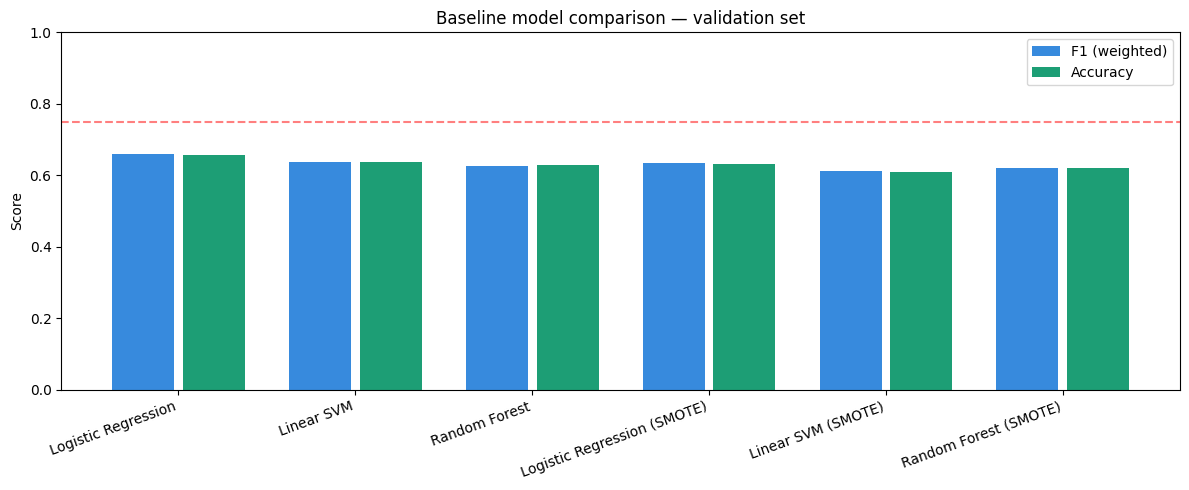

In [ ]:
# 9c. Baseline comparison chart
all_results = {**baseline_results, **smote_results}
names = list(all_results.keys())
f1_scores = [all_results[n]['f1'] for n in names]
acc_scores = [all_results[n]['accuracy'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - 0.2, f1_scores, 0.35, label='F1 (weighted)', color='#378ADD')
bars2 = ax.bar(x + 0.2, acc_scores, 0.35, label='Accuracy', color='#1D9E75')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baseline model comparison — validation set')
ax.legend()
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target F1=0.75')
plt.tight_layout()
plt.show()

---
## STEP 10 — Single-Task DistilBERT




In [ ]:
# 10a. Dataset class for PyTorch
# PyTorch needs data in a specific format
# Tokenisation is cached so it only runs once across all sessions.
SINGLETASK_DIR = f'{MODEL_DIR}/distilbert_singletask'

tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

class SingleTaskDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        # Tokenize all texts at once — converts words to token IDs the model understands
        self.encodings = tokenizer(
            list(df['full_text']),
            truncation=True, padding=True,
            max_length=max_len
        )
        self.labels = list(df['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Cache the tokenised datasets — tokenisation is slow (minutes), caching makes it instant
st_train = cache('st_train_enc', lambda: SingleTaskDataset(train, tokenizer_bert))
st_val   = cache('st_val_enc',   lambda: SingleTaskDataset(val,   tokenizer_bert))
st_test  = cache('st_test_enc',  lambda: SingleTaskDataset(test,  tokenizer_bert))
print('Single-task datasets ready')

Using: cuda
[CACHE MISS] 'st_train_enc' — computing ...
[SAVED]      'st_train_enc' in 6.1s → /content/drive/My Drive/Colab Notebooks/FYP/cache/st_train_enc.pkl
[CACHE MISS] 'st_val_enc' — computing ...
[SAVED]      'st_val_enc' in 1.6s → /content/drive/My Drive/Colab Notebooks/FYP/cache/st_val_enc.pkl
[CACHE MISS] 'st_test_enc' — computing ...
[SAVED]      'st_test_enc' in 2.0s → /content/drive/My Drive/Colab Notebooks/FYP/cache/st_test_enc.pkl
Single-task datasets ready


In [ ]:
#10b. Train or load

if os.path.exists(f'{SINGLETASK_DIR}/config.json'):
    # Model already trained in a previous session
    print(f'[SKIP] Single-task model found — loading from {SINGLETASK_DIR} ...')
    st_model = DistilBertForSequenceClassification.from_pretrained(SINGLETASK_DIR)
    st_model.to(device)
    training_args = TrainingArguments(
        output_dir='./st_results',
        per_device_eval_batch_size=64,
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(model=st_model, args=training_args)
else:
    print('Training single-task DistilBERT ...')
    st_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=3
    )
    training_args = TrainingArguments(
        output_dir='./st_results',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        warmup_steps=200,
        weight_decay=0.01,
        eval_strategy='epoch',      # evaluate at end of each epoch
        save_strategy='epoch',
        load_best_model_at_end=True,
        fp16=torch.cuda.is_available(),   # mixed precision — halves memory, speeds training
        logging_steps=50,
    )
    trainer = Trainer(
        model=st_model,
        args=training_args,
        train_dataset=st_train,
        eval_dataset=st_val,
    )
    trainer.train()
    # Save to Drive — model is preserved across Colab sessions
    st_model.save_pretrained(SINGLETASK_DIR)
    tokenizer_bert.save_pretrained(SINGLETASK_DIR)
    print(f'Single-task model saved → {SINGLETASK_DIR}')

Training single-task DistilBERT ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.516809,0.496133
2,0.287893,0.538298
3,0.116829,0.690563


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Single-task model saved → /content/drive/My Drive/Colab Notebooks/FYP/models/distilbert_singletask


In [ ]:
# 10c. Evaluate single-task model on test set
st_preds = trainer.predict(st_test)
st_pred_labels = st_preds.predictions.argmax(-1)

st_f1  = f1_score(test['sentiment'], st_pred_labels, average='weighted')
st_acc = accuracy_score(test['sentiment'], st_pred_labels)

print('=== Single-task DistilBERT — Test Set Results ===')
print(classification_report(
    test['sentiment'], st_pred_labels,
    target_names=['Neutral', 'Negative', 'Positive']
))
print(f'Weighted F1: {st_f1:.3f}  |  Accuracy: {st_acc:.3f}')

# Store for final comparison
all_results['DistilBERT (single-task)'] = {'f1': st_f1, 'accuracy': st_acc}

=== Single-task DistilBERT — Test Set Results ===
              precision    recall  f1-score   support

     Neutral       0.80      0.74      0.77      3063
    Negative       0.78      0.90      0.83      3081
    Positive       0.83      0.69      0.75      1345

    accuracy                           0.79      7489
   macro avg       0.80      0.77      0.79      7489
weighted avg       0.80      0.79      0.79      7489

Weighted F1: 0.792  |  Accuracy: 0.795


---
## STEP 11 -Multi-Task Learning Model (MTL) - Main Novelty



In [ ]:
#  11a. Multi-task dataset
# this loads ALL THREE labels per row.
MTL_BEST_PATH = f'{MODEL_DIR}/mtl_model_best.pt'
MTL_CKPT_PATH = f'{MODEL_DIR}/mtl_checkpoint.pt'

class MTLDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(df['full_text']),
            truncation=True, padding=True,
            max_length=max_len
        )
        # Three separate label arrays — one per task
        self.sarcasm   = torch.tensor(df['sarcasm_flag'].astype(int).values, dtype=torch.long)
        self.sentiment = torch.tensor(df['sentiment'].astype(int).values,    dtype=torch.long)
        self.slang     = torch.tensor(df['slang_flag'].astype(int).values,   dtype=torch.long)

    def __len__(self):
        return len(self.sarcasm)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['sarcasm']   = self.sarcasm[idx]
        item['sentiment'] = self.sentiment[idx]
        item['slang']     = self.slang[idx]
        return item

# Cache the tokenised datasets
mtl_train_ds = cache('mtl_train_enc', lambda: MTLDataset(train, tokenizer_bert))
mtl_val_ds   = cache('mtl_val_enc',   lambda: MTLDataset(val,   tokenizer_bert))
mtl_test_ds  = cache('mtl_test_enc',  lambda: MTLDataset(test,  tokenizer_bert))

# pin_memory=True + num_workers=2 speed up Host→GPU batch transfer

train_loader = DataLoader(mtl_train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(mtl_val_ds,   batch_size=64,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(mtl_test_ds,  batch_size=64,
                          num_workers=2, pin_memory=True)
print('MTL datasets and loaders ready')

[CACHE MISS] 'mtl_train_enc' — computing ...
[SAVED]      'mtl_train_enc' in 6.5s → /content/drive/My Drive/Colab Notebooks/FYP/cache/mtl_train_enc.pkl
[CACHE MISS] 'mtl_val_enc' — computing ...
[SAVED]      'mtl_val_enc' in 3.1s → /content/drive/My Drive/Colab Notebooks/FYP/cache/mtl_val_enc.pkl
[CACHE MISS] 'mtl_test_enc' — computing ...
[SAVED]      'mtl_test_enc' in 1.2s → /content/drive/My Drive/Colab Notebooks/FYP/cache/mtl_test_enc.pkl
MTL datasets and loaders ready


In [ ]:
# 11b. MTL model architecture
# One shared DistilBERT encoder + three independent classification heads.

class MTLSentimentModel(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # Shared encoder — learns features useful for all three tasks simultaneously
        self.encoder = DistilBertModel.from_pretrained('distilbert-base-uncased')
        hidden = self.encoder.config.hidden_size  # 768

        # Dropout applied before each head to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Three independent heads — each specialises on one task
        self.sarcasm_head   = nn.Linear(hidden, 2)   # binary: sarcastic or not
        self.sentiment_head = nn.Linear(hidden, 3)   # 3-class: neg/neu/pos
        self.slang_head     = nn.Linear(hidden, 2)   # binary: slang or not

    def forward(self, input_ids, attention_mask):
        # Run text through the shared encoder
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Take the [CLS] token
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        # Each head produces independent logits
        return (
            self.sarcasm_head(cls),    # (batch, 2)
            self.sentiment_head(cls),  # (batch, 3)
            self.slang_head(cls),      # (batch, 2)
        )

In [ ]:
# 11c. Training and evaluation functions
def train_one_epoch(model, loader, optimizer, device,
                    alpha=1.0, beta=1.0, gamma=0.5):
    """
    Train for one epoch using weighted combined loss.

    alpha = weight for sarcasm loss   (1.0 — high quality labels)
    beta  = weight for sentiment loss (1.0 — high quality RoBERTa labels)
    gamma = weight for slang loss     (0.5 — lower because slang labels are noisier)

    Total loss = alpha*L_sarcasm + beta*L_sentiment + gamma*L_slang
    All three losses backpropagate through the shared encoder simultaneously.
    """
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        sarc_labels    = batch['sarcasm'].to(device)
        sent_labels    = batch['sentiment'].to(device)
        slang_labels   = batch['slang'].to(device)

        optimizer.zero_grad()
        sarc_logits, sent_logits, slang_logits = model(input_ids, attention_mask)

        # Individual task losses
        loss_sarc  = criterion(sarc_logits,  sarc_labels)
        loss_sent  = criterion(sent_logits,  sent_labels)
        loss_slang = criterion(slang_logits, slang_labels)

        # Weighted combined loss
        loss = alpha * loss_sarc + beta * loss_sent + gamma * loss_slang
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_mtl(model, loader, device):
    """Evaluate the MTL model and return per-task F1 scores and predictions."""
    model.eval()
    all_sarc, all_sent, all_slang    = [], [], []
    true_sarc, true_sent, true_slang = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sarc_l, sent_l, slang_l = model(input_ids, attention_mask)

            all_sarc.extend(sarc_l.argmax(1).cpu().numpy())
            all_sent.extend(sent_l.argmax(1).cpu().numpy())
            all_slang.extend(slang_l.argmax(1).cpu().numpy())
            true_sarc.extend(batch['sarcasm'].numpy())
            true_sent.extend(batch['sentiment'].numpy())
            true_slang.extend(batch['slang'].numpy())

    metrics = {
        'sarcasm_f1':   f1_score(true_sarc,  all_sarc,  average='weighted'),
        'sentiment_f1': f1_score(true_sent,  all_sent,  average='weighted'),
        'slang_f1':     f1_score(true_slang, all_slang, average='weighted'),
    }
    return metrics, (true_sarc, all_sarc), (true_sent, all_sent), (true_slang, all_slang)

In [ ]:
# 11d. Checkpoint helpers
def save_checkpoint(model, optimizer, epoch, best_f1, history):
    """
    Save full training state after every epoch — enables crash recovery.
    If Colab disconnects on epoch 2 of 3, training resumes from epoch 2,
    not from epoch 0.
    """
    torch.save(
        {
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_f1':         best_f1,
            'history':         history,
        },
        MTL_CKPT_PATH,
    )
    print(f'  [CHECKPOINT] Saved after epoch {epoch + 1}')


def load_checkpoint(model, optimizer):
    """Load checkpoint if it exists; return (start_epoch, best_f1, history)."""
    if not os.path.exists(MTL_CKPT_PATH):
        return 0, 0.0, []
    ckpt = torch.load(MTL_CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    print(f'[RESUME] Loaded checkpoint — starting from epoch {ckpt["epoch"] + 1}')
    return ckpt['epoch'] + 1, ckpt['best_f1'], ckpt['history']

In [ ]:
#11e. Train the MTL model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

mtl_model = MTLSentimentModel(dropout=0.3).to(device)

# AdamW with small learning rate
optimizer = torch.optim.AdamW(mtl_model.parameters(), lr=2e-5, weight_decay=0.01)

if os.path.exists(MTL_BEST_PATH):
    # All epochs already completed in a previous session
    print(f'[SKIP] MTL best model found — loading from {MTL_BEST_PATH} ...')
    mtl_model.load_state_dict(torch.load(MTL_BEST_PATH, map_location=device))
    history = []
else:
    print(f'Training MTL model on: {device}')
    # Load checkpoint if one exists (resumes from last completed epoch)
    start_epoch, best_sent_f1, history = load_checkpoint(mtl_model, optimizer)

    for epoch in range(start_epoch, 3):
        train_loss = train_one_epoch(
            mtl_model, train_loader, optimizer, device,
            alpha=1.0, beta=1.0, gamma=0.5
        )
        metrics, _, _, _ = evaluate_mtl(mtl_model, val_loader, device)
        history.append({'epoch': epoch + 1, 'loss': train_loss, **metrics})

        print(
            f'Epoch {epoch+1}/3 | Loss: {train_loss:.4f} | '
            f'Sarcasm F1: {metrics["sarcasm_f1"]:.3f} | '
            f'Sentiment F1: {metrics["sentiment_f1"]:.3f} | '
            f'Slang F1: {metrics["slang_f1"]:.3f}'
        )

        # Save epoch checkpoint
        save_checkpoint(mtl_model, optimizer, epoch, best_sent_f1, history)

        # Save the best model based on sentiment F1 (primary task)
        if metrics['sentiment_f1'] > best_sent_f1:
            best_sent_f1 = metrics['sentiment_f1']
            torch.save(mtl_model.state_dict(), MTL_BEST_PATH)
            print(f'  [BEST MODEL] Saved (sentiment F1: {best_sent_f1:.3f})')

Training on: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training MTL model on: cuda
Epoch 1/3 | Loss: 1.4861 | Sarcasm F1: 0.695 | Sentiment F1: 0.792 | Slang F1: 0.776
  [CHECKPOINT] Saved after epoch 1
  [BEST MODEL] Saved (sentiment F1: 0.792)
Epoch 2/3 | Loss: 1.1226 | Sarcasm F1: 0.703 | Sentiment F1: 0.797 | Slang F1: 0.856
  [CHECKPOINT] Saved after epoch 2
  [BEST MODEL] Saved (sentiment F1: 0.797)
Epoch 3/3 | Loss: 0.8776 | Sarcasm F1: 0.712 | Sentiment F1: 0.802 | Slang F1: 0.898
  [CHECKPOINT] Saved after epoch 3
  [BEST MODEL] Saved (sentiment F1: 0.802)


In [ ]:
#11f. Final MTL evaluation on test set

mtl_model.load_state_dict(torch.load(MTL_BEST_PATH, map_location=device))

test_metrics, sarc_pair, sent_pair, slang_pair = evaluate_mtl(
    mtl_model, test_loader, device
)

print('=== MTL Model — Test Set Results ===')
print('\n--- Sarcasm ---')
print(classification_report(sarc_pair[0], sarc_pair[1],
      target_names=['Not sarcastic','Sarcastic']))
print('\n--- Sentiment ---')
print(classification_report(sent_pair[0], sent_pair[1],
      target_names=['Neutral','Negative','Positive']))
print('\n--- Slang ---')
print(classification_report(slang_pair[0], slang_pair[1],
      target_names=['No slang','Has slang']))

# Store sentiment F1 for final comparison
all_results['MTL DistilBERT (sentiment)'] = {
    'f1': test_metrics['sentiment_f1'],
    'accuracy': accuracy_score(sent_pair[0], sent_pair[1])
}

=== MTL Model — Test Set Results ===

--- Sarcasm ---
               precision    recall  f1-score   support

Not sarcastic       0.70      0.74      0.72      3617
    Sarcastic       0.74      0.71      0.73      3872

     accuracy                           0.72      7489
    macro avg       0.72      0.72      0.72      7489
 weighted avg       0.72      0.72      0.72      7489


--- Sentiment ---
              precision    recall  f1-score   support

     Neutral       0.79      0.77      0.78      3063
    Negative       0.81      0.88      0.84      3081
    Positive       0.83      0.71      0.76      1345

    accuracy                           0.80      7489
   macro avg       0.81      0.79      0.80      7489
weighted avg       0.80      0.80      0.80      7489


--- Slang ---
              precision    recall  f1-score   support

    No slang       0.84      0.95      0.89      3222
   Has slang       0.96      0.86      0.91      4267

    accuracy                      

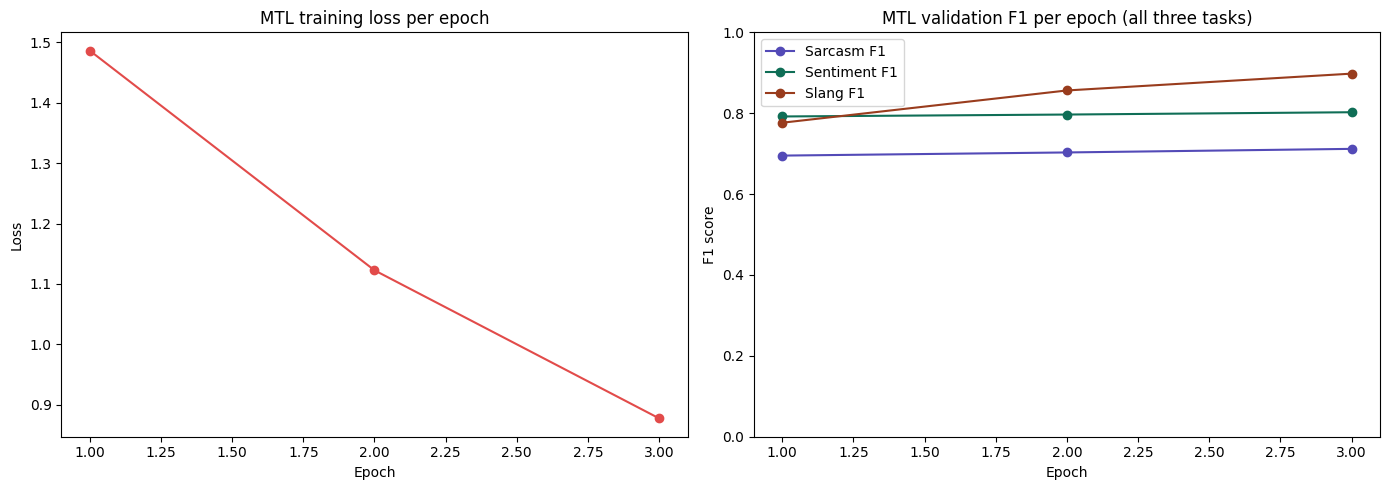

In [ ]:
# 11g. Training history plot
if history:
    history_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df['epoch'], history_df['loss'], marker='o', color='#E24B4A')
    axes[0].set_title('MTL training loss per epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    for col, label, color in [
        ('sarcasm_f1',   'Sarcasm F1',   '#534AB7'),
        ('sentiment_f1', 'Sentiment F1', '#0F6E56'),
        ('slang_f1',     'Slang F1',     '#993C1D'),
    ]:
        axes[1].plot(history_df['epoch'], history_df[col],
                     marker='o', label=label, color=color)

    axes[1].set_title('MTL validation F1 per epoch (all three tasks)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 score')
    axes[1].legend()
    axes[1].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print('(Training history not available — model was loaded from a saved checkpoint)')

---
## STEP 12 — Full Model Comparison & Results


In [ ]:
#12a. Results tab
results_df = pd.DataFrame([
    {'Model': name, 'F1 (weighted)': v['f1'], 'Accuracy': v['accuracy']}
    for name, v in all_results.items()
])
results_df = results_df.sort_values('F1 (weighted)', ascending=False)
results_df['F1 (weighted)'] = results_df['F1 (weighted)'].round(3)
results_df['Accuracy']      = results_df['Accuracy'].round(3)

print('=== Full Model Comparison (Sentiment Classification — Test Set) ===')
print(results_df.to_string(index=False))

=== Full Model Comparison (Sentiment Classification — Test Set) ===
                      Model  F1 (weighted)  Accuracy
 MTL DistilBERT (sentiment)          0.803     0.804
   DistilBERT (single-task)          0.792     0.795
        Logistic Regression          0.659     0.657
                 Linear SVM          0.637     0.636
Logistic Regression (SMOTE)          0.633     0.630
              Random Forest          0.625     0.627
      Random Forest (SMOTE)          0.620     0.620
         Linear SVM (SMOTE)          0.612     0.609


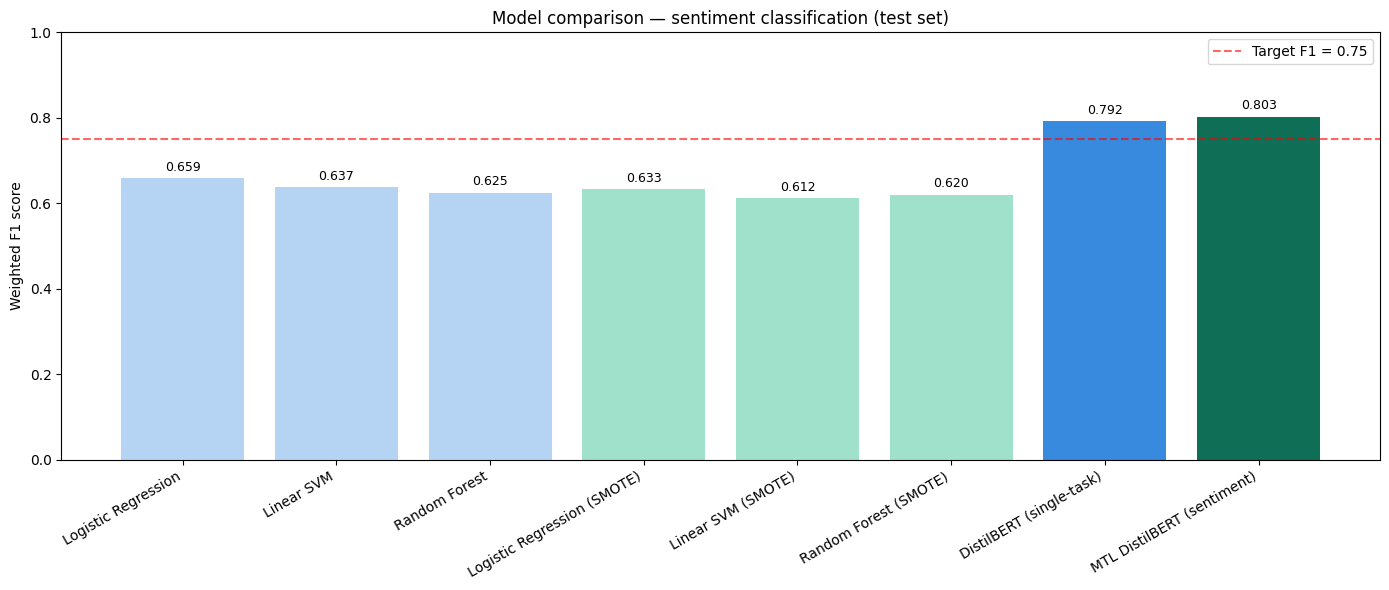

In [ ]:
#12b. Comparison bar chart
# show the progression
ordered = [
    'Logistic Regression', 'Linear SVM', 'Random Forest',
    'Logistic Regression (SMOTE)', 'Linear SVM (SMOTE)', 'Random Forest (SMOTE)',
    'DistilBERT (single-task)', 'MTL DistilBERT (sentiment)'
]
ordered = [m for m in ordered if m in all_results]
f1_vals = [all_results[m]['f1'] for m in ordered]
colors = [
    '#B5D4F4','#B5D4F4','#B5D4F4',   # baseline — light blue
    '#9FE1CB','#9FE1CB','#9FE1CB',   # SMOTE    — light teal
    '#378ADD',                        # single-task BERT — blue
    '#0F6E56',                        # MTL — dark teal
]
bar_colors = colors[:len(ordered)]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(ordered)), f1_vals, color=bar_colors)
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels(ordered, rotation=30, ha='right')
ax.set_ylabel('Weighted F1 score')
ax.set_title('Model comparison — sentiment classification (test set)')
ax.set_ylim(0, 1)
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.6, label='Target F1 = 0.75')
ax.legend()

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

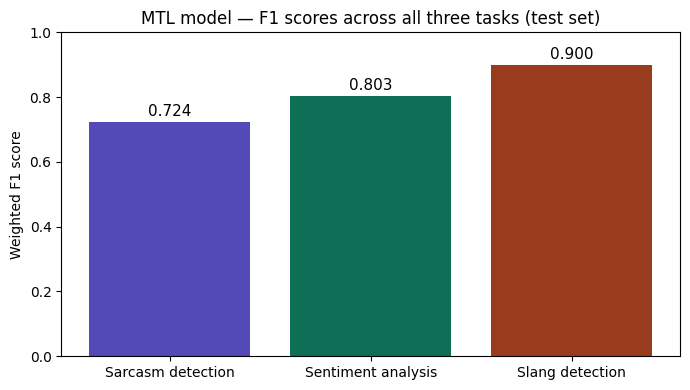


=== MTL Model Summary ===
Sarcasm detection        : 0.724
Sentiment analysis       : 0.803
Slang detection          : 0.900

The MTL model simultaneously produces all three outputs from one forward pass.
No other model in this comparison does this.


In [ ]:
#12c. MTL unique value — three tasks in one
# This chart only makes sense for the MTL model — baselines only do sentiment
mtl_task_results = {
    'Sarcasm detection':   test_metrics['sarcasm_f1'],
    'Sentiment analysis':  test_metrics['sentiment_f1'],
    'Slang detection':     test_metrics['slang_f1'],
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    mtl_task_results.keys(),
    mtl_task_results.values(),
    color=['#534AB7', '#0F6E56', '#993C1D']
)
for bar, val in zip(bars, mtl_task_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Weighted F1 score')
ax.set_title('MTL model — F1 scores across all three tasks (test set)')
plt.tight_layout()
plt.show()

print('\n=== MTL Model Summary ===')
for task, score in mtl_task_results.items():
    print(f'{task:25s}: {score:.3f}')
print('\nThe MTL model simultaneously produces all three outputs from one forward pass.')
print('No other model in this comparison does this.')

In [ ]:
#12d. Save final results table to Drive
results_path = f'{BASE_DIR}/model_results.csv'
results_df.to_csv(results_path, index=False)
print(f'Results table saved → {results_path}')

Results table saved → /content/drive/My Drive/Colab Notebooks/FYP/model_results.csv


In [3]:
#  13. Install Gradio
!pip install gradio -q

import gradio as gr
import torch
import torch.nn as nn
import pickle
import os
import re
import io
from collections import defaultdict
from transformers import DistilBertTokenizerFast, DistilBertModel
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz

# Paths
BASE_DIR  = '/content/drive/My Drive/Colab Notebooks/FYP'
CACHE_DIR = '/content/drive/My Drive/Colab Notebooks/FYP/cache'
MODEL_DIR = '/content/drive/My Drive/Colab Notebooks/FYP/models'
MTL_BEST_PATH = '/content/drive/My Drive/Colab Notebooks/FYP/models/mtl_model_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dashboard running on: {device}')

#Re-define the model class
class MTLSentimentModel(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained('distilbert-base-uncased')
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.sarcasm_head   = nn.Linear(hidden, 2)
        self.sentiment_head = nn.Linear(hidden, 3)
        self.slang_head     = nn.Linear(hidden, 2)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return (
            self.sarcasm_head(cls),
            self.sentiment_head(cls),
            self.slang_head(cls),
        )

# Load all artefacts once at startup
print('Loading MTL model …')
mtl_model = MTLSentimentModel(dropout=0.3).to(device)
mtl_model.load_state_dict(torch.load(MTL_BEST_PATH, map_location=device))
mtl_model.eval()

print('Loading tokeniser …')
tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print('Loading slang dictionary …')
slang_data1 = pd.read_csv(f'{DATA_DIR}/genz_slang.csv')
slang_data2 = pd.read_csv(f'{DATA_DIR}/all_slangs.csv')
slang_data2 = slang_data2.rename(columns={'Slang': 'keyword', 'Description': 'description'})
merged_slang = pd.concat(
    [slang_data1[['keyword', 'description']], slang_data2[['keyword', 'description']]],
    ignore_index=True
).drop_duplicates(subset=['keyword'])
slang_dict  = dict(zip(merged_slang['keyword'].str.lower(), merged_slang['description']))
slang_terms = list(slang_dict.keys())
slang_set   = set(slang_dict.keys())

prefix_index: dict = defaultdict(list)
for term in slang_terms:
    if isinstance(term, str) and len(term) >= 3:
        prefix_index[term[:3]].append(term)

GENZ_PATTERNS = [
    r'\bfr\s?fr\b', r'\bno\s?cap\b', r'\bim\s?dead\b',
    r'\bngl\b', r'\bidk\b', r'\bperiodt?\b', r'\bslay+\b',
    r'\blow\s?key\b', r'\bhigh\s?key\b', r'\bboutta\b',
    r'\bvibing\b', r'\bsnatched\b',
    r'\bate\s+(that\s+)?(and\s+left\s+no\s+crumbs?)?\b',
    r'\brent\s?free\b', r'\bit\s?gives?\b', r"\bchef'?s\s?kiss\b",
]
COMBINED_PATTERN = re.compile('|'.join(GENZ_PATTERNS), re.IGNORECASE)

print('All artefacts loaded — dashboard ready.')

#  Helper: detect slang (v2 — same as training)
def detect_slang_v2(comment: str, threshold: int = 85):
    if not isinstance(comment, str):
        return 0, ''
    text_lower = comment.lower()
    words      = re.findall(r'\b\w+\b', text_lower)
    detected   = set()
    for word in words:
        if len(word) < 3:
            continue
        if word in slang_set:
            detected.add(word)
            continue
        candidates = prefix_index.get(word[:3], [])
        if candidates:
            match, score, _ = process.extractOne(word, candidates, scorer=fuzz.ratio)
            if score >= threshold:
                detected.add(match)
    for m in COMBINED_PATTERN.finditer(text_lower):
        detected.add(m.group().strip())
    return (1 if detected else 0), ', '.join(detected)

# Helper: run MTL inference on a list of texts
SENTIMENT_MAP = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
SENTIMENT_EMOJI = {'Neutral': '😐', 'Negative': '😠', 'Positive': '😊'}

def run_inference(texts: list[str]) -> pd.DataFrame:
    """Run MTL forward pass on a list of raw comment strings.
    Returns a DataFrame with one row per comment."""
    enc = tokenizer_bert(
        texts, truncation=True, padding=True,
        max_length=128, return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        sarc_logits, sent_logits, slang_logits = mtl_model(input_ids, attention_mask)

    sarc_preds  = sarc_logits.argmax(1).cpu().numpy()
    sent_preds  = sent_logits.argmax(1).cpu().numpy()
    slang_preds = slang_logits.argmax(1).cpu().numpy()

    rows = []
    for i, text in enumerate(texts):
        _, slang_terms_found = detect_slang_v2(text)
        rows.append({
            'Comment'   : text[:120] + ('…' if len(text) > 120 else ''),
            'Sarcasm'   : '✅ Yes' if sarc_preds[i] == 1 else '❌ No',
            'Sentiment' : SENTIMENT_EMOJI[SENTIMENT_MAP[sent_preds[i]]] + ' ' + SENTIMENT_MAP[sent_preds[i]],
            'Slang'     : '✅ Yes' if slang_preds[i] == 1 else '❌ No',
            'Slang terms': slang_terms_found if slang_terms_found else '—',
        })
    return pd.DataFrame(rows)

# Summary stats for charts
def make_summary(df_results: pd.DataFrame) -> str:
    n = len(df_results)
    sarc_rate  = (df_results['Sarcasm']   == '✅ Yes').mean()
    slang_rate = (df_results['Slang']     == '✅ Yes').mean()
    pos_rate   = df_results['Sentiment'].str.contains('Positive').mean()
    neg_rate   = df_results['Sentiment'].str.contains('Negative').mean()
    neu_rate   = df_results['Sentiment'].str.contains('Neutral').mean()

    lines = [
        f"**{n} comment{'s' if n != 1 else ''} analysed",
        "",
        f"😏 Sarcasm detected: **{sarc_rate:.0%}** of comments",
        f"🗣️ Slang detected:   **{slang_rate:.0%}** of comments",
        "",
        "**Sentiment breakdown:**",
        f"  😊 Positive: {pos_rate:.0%}",
        f"  😠 Negative: {neg_rate:.0%}",
        f"  😐 Neutral:  {neu_rate:.0%}",
    ]
    return "\n".join(lines)

# Gradio callbacks
def analyse_single(comment: str, parent: str):
    if not comment.strip():
        return None, "⚠️ Please enter a comment."
    text = comment.strip()
    if parent.strip():
        text = text + ' [ ' + parent.strip() + ']'
    df = run_inference([text])
    return df, make_summary(df)

def analyse_csv(file):
    if file is None:
        return None, "⚠️ Please upload a CSV file."
    try:
        raw = pd.read_csv(file.name)
    except Exception as e:
        return None, f"❌ Could not read CSV: {e}"

    # Accept a 'comment' column or use the first column
    if 'comment' in raw.columns:
        texts = raw['comment'].fillna('').astype(str).tolist()
    else:
        texts = raw.iloc[:, 0].fillna('').astype(str).tolist()

    # Optional parent_comment column for context
    if 'parent_comment' in raw.columns:
        parents = raw['parent_comment'].fillna('').astype(str).tolist()
        texts = [
            t + ' [ ' + p + ']' if p.strip() else t
            for t, p in zip(texts, parents)
        ]

    if len(texts) > 200:
        texts = texts[:200]
        note = "⚠️ Truncated to first 200 rows.\n\n"
    else:
        note = ""

    df = run_inference(texts)
    return df, note + make_summary(df)

# Build Gradio interface
DESCRIPTION = """
## FYP Dashboard — Context-Aware Sarcasm, Sentiment & Slang Detector
Powered by the **Multi-Task DistilBERT** model (MTL) trained in this notebook.

Analyse individual Reddit comments or upload a CSV for batch processing.
No retraining required — all model weights are loaded from Google Drive.
"""

with gr.Blocks(title="FYP — MTL Sentiment Dashboard", theme=gr.themes.Soft()) as demo:
    gr.Markdown(DESCRIPTION)

    with gr.Tab("🔍 Single Comment"):
        with gr.Row():
            with gr.Column():
                single_comment = gr.Textbox(
                    label="Comment",
                    placeholder="Enter a Reddit comment here …",
                    lines=3,
                )
                single_parent = gr.Textbox(
                    label="Parent comment (optional — adds context)",
                    placeholder="The comment this is replying to …",
                    lines=2,
                )
                single_btn = gr.Button("Analyse", variant="primary")
            with gr.Column():
                single_summary = gr.Markdown(label="Summary")
        single_table = gr.Dataframe(label="Results", wrap=True)
        single_btn.click(
            fn=analyse_single,
            inputs=[single_comment, single_parent],
            outputs=[single_table, single_summary],
        )
        gr.Examples(
            examples=[
                ["Oh great, another Monday.", "Hope your weekend was good!"],
                ["This new update is actually fire no cap fr fr", ""],
                ["The server is down again.", ""],
                ["Yeah that went really well lmao", "How did the presentation go?"],
            ],
            inputs=[single_comment, single_parent],
            label="Try these examples",
        )

    with gr.Tab("📂 Batch CSV Upload"):
        gr.Markdown("""
Upload a CSV with a **`comment`** column (and optionally a **`parent_comment`** column).
If no `comment` column is found, the first column is used. Max 200 rows per run.
        """)
        with gr.Row():
            csv_file = gr.File(label="Upload CSV", file_types=[".csv"])
            csv_btn  = gr.Button("Analyse CSV", variant="primary")
        csv_summary = gr.Markdown(label="Summary")
        csv_table   = gr.Dataframe(label="Results", wrap=True)
        csv_btn.click(
            fn=analyse_csv,
            inputs=[csv_file],
            outputs=[csv_table, csv_summary],
        )

    gr.Markdown("""
---
**Model:** Multi-Task DistilBERT — one shared encoder, three task heads (sarcasm · sentiment · slang)
**Weights:** loaded from `{}/mtl_model_best.pt`
""".format(MODEL_DIR))

demo.launch(share=True, debug=False)

Dashboard running on: cuda
Loading MTL model …


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading tokeniser …
Loading slang dictionary …
All artefacts loaded — dashboard ready.


/tmp/ipykernel_675/3954153162.py:211: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="FYP — MTL Sentiment Dashboard", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a5c5d47ac68083625d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
